# Quote Agent: memory and human approval

This demo turns a customer RFQ into a product quote. The quote agent uses an LLM to resolve products, consider substitutes, ask for human judgment, and produce the quote content. A second LLM decides whether human feedback is worth remembering.

Deterministic code is limited to trusted data access, the explicit approval gate, and the idempotent mock ERP write. The implementation lives in `src/quote_agent`; this notebook uses the same graph exposed to LangGraph Studio and the same cases used by the Pytest and LangSmith evaluations.


## 1. Setup

Load local credentials without displaying their values, then import the shared package.


In [1]:
import json
import os
from pathlib import Path
from uuid import uuid4

from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from langgraph.types import Command

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "pyproject.toml").exists()
    else Path.cwd().parent
)
load_dotenv(PROJECT_ROOT / ".env")
if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "rfq-demo-agent")
else:
    os.environ["LANGSMITH_TRACING"] = "false"

from quote_agent.domain import (
    ACCOUNTS,
    APPROVAL_POLICIES,
    DISTRIBUTOR,
    INITIAL_DISTRIBUTOR_MEMORY,
    PRODUCTS,
    AccountMemory,
    read_account_memory,
)
from quote_agent.graph import (
    ACCOUNT_PROMPT,
    MEMORY_PROMPT,
    QUOTE_AGENT_PROMPT,
    TOOLS,
    QuoteWorkflowState,
    reset_local_runtime,
    tool_sequence,
)

print(f"OpenAI key available: {bool(os.getenv('OPENAI_API_KEY'))}")
print(
    "LangSmith tracing enabled: "
    f"{os.getenv('LANGSMITH_TRACING') == 'true'}"
)


OpenAI key available: True
LangSmith tracing enabled: True


In [2]:
def show_json(value) -> None:
    print(json.dumps(value, indent=2, default=str))


def memory_records(runtime, account_id: str) -> dict:
    return read_account_memory(runtime.store, account_id).model_dump()


def show_run(state: dict) -> None:
    show_json({
        "account": state.get("account_id"),
        "tools": tool_sequence(state),
        "agent_output": state.get("structured_response"),
        "approval": state.get("approval"),
        "quote": state.get("quote"),
    })


## 2. Business environment setup

The agent works against a deliberately small distributor catalog: two accounts, seven products, trusted price and stock facts, and one approval policy. These fixtures stand in for read APIs and an ERP boundary.


In [3]:
show_json({
    "distributor": DISTRIBUTOR,
    "accounts": {key: value["name"] for key, value in ACCOUNTS.items()},
    "products": [
        {"sku": item["sku"], "brand": item["brand"], "name": item["name"]}
        for item in PRODUCTS.values()
    ],
    "approval_policies": APPROVAL_POLICIES,
})

{
  "distributor": {
    "id": "acme",
    "name": "Acme Industrial Supply"
  },
  "accounts": {
    "nova": "Nova Robotics",
    "peak": "Peak Manufacturing"
  },
  "products": [
    {
      "sku": "VAL-SS-100-FLOWFORGE",
      "brand": "FlowForge",
      "name": "1-inch stainless ball valve"
    },
    {
      "sku": "VAL-SS-150-FLOWFORGE",
      "brand": "FlowForge",
      "name": "1.5-inch stainless ball valve"
    },
    {
      "sku": "VAL-SS-100-BLUEPEAK",
      "brand": "BluePeak",
      "name": "1-inch stainless ball valve"
    },
    {
      "sku": "VAL-SS-100-NORTHSTAR",
      "brand": "Northstar",
      "name": "1-inch stainless ball valve"
    },
    {
      "sku": "BRG-6205-AXIS",
      "brand": "Axis",
      "name": "6205 sealed ball bearing"
    },
    {
      "sku": "PMP-100-RIVET",
      "brand": "Rivet",
      "name": "1-inch centrifugal pump"
    },
    {
      "sku": "PMP-100-CASCADE",
      "brand": "Cascade",
      "name": "1-inch centrifugal pump"
    }
  ],
  "

## 3. State, memory, and policy

- **State** belongs to one RFQ thread: messages, the agent output, approval, and quote.
- **Memory** is one account profile with preferred SKUs and concise preference sentences. The Quote Agent reads it automatically before each LLM call.
- **Policy** is limited to the explicit human-approval rule and protected ERP write.


In [4]:
show_json({
    "state_fields": list(QuoteWorkflowState.__annotations__),
    "account_memory_schema": AccountMemory.model_json_schema()["properties"],
    "distributor_memory": INITIAL_DISTRIBUTOR_MEMORY,
    "approval_policy": APPROVAL_POLICIES,
})


{
  "state_fields": [
    "messages",
    "jump_to",
    "structured_response",
    "rfq",
    "account_id",
    "processed_human_input_ids",
    "approval",
    "quote",
    "memory_updated",
    "status"
  ],
  "account_memory_schema": {
    "preferred_skus": {
      "items": {
        "type": "string"
      },
      "title": "Preferred Skus",
      "type": "array"
    },
    "preferences": {
      "items": {
        "type": "string"
      },
      "title": "Preferences",
      "type": "array"
    }
  },
  "distributor_memory": [
    "Approved valve-substitute brands are FlowForge, BluePeak, and Northstar.",
    "Only propose SKUs listed as substitutes for the requested product.",
    "When a requested product is unavailable from stock, evaluate its listed substitutes before drafting a backorder quote.",
    "Never silently replace a requested SKU; clearly identify any proposed substitute.",
    "When several compatible approved substitutes are in stock and no account preference appl

## 4. Agent tools and prompts

The Quote Agent has three tools:

1. `search_products` searches the catalog and returns possible substitutes.
2. `get_quote_facts` returns trusted account price, stock, margin, and lead time.
3. `request_human` pauses for ambiguity or substitution judgment.

The Quote LLM handles product and substitution reasoning. After any human response, the Memory LLM decides whether it contains a reusable account preference.


In [5]:
show_json({
    "tools": [
        {"name": item.name, "description": item.description}
        for item in TOOLS
    ],
    "account_prompt": ACCOUNT_PROMPT,
    "quote_prompt": QUOTE_AGENT_PROMPT,
    "memory_prompt": MEMORY_PROMPT,
})


{
  "tools": [
    {
      "name": "search_products",
      "description": "Search the catalog. Multiple matches mean the request is ambiguous."
    },
    {
      "name": "get_quote_facts",
      "description": "Get trusted price, margin, availability, and lead time for the account."
    },
    {
      "name": "request_human",
      "description": "Ask a human to resolve ambiguity or judge a substitution.\n\nCall this before drafting any cross-SKU substitute unless exact account\nmemory already names the proposed SKU as preferred."
    }
  ],
  "account_prompt": "Identify the customer account referenced by the RFQ.\nChoose only from the supplied account directory. Do not infer a new account.",
  "quote_prompt": "Draft quotes with tools and memory.\nUse search_products, then inspect the requested item and each substitute with get_quote_facts.\nAfter searching, compare the matches with account-memory preferred_skus first. If exactly one relevant match is preferred, select it without ask

## 5. Graph

The outer graph is intentionally small. `identify_account` uses an LLM to recognize the customer, while `quote_agent` is the `create_agent` subgraph. The parent workflow handles memory after human input, checks the explicit approval rule, pauses when approval is required, and writes the quote.


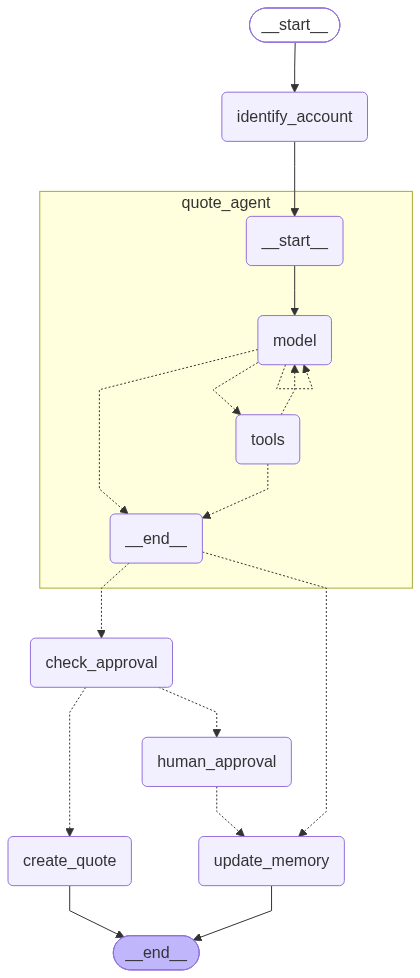

In [6]:
runtime = reset_local_runtime()
display(Image(runtime.graph.get_graph(xray=True).draw_mermaid_png()))

## 6. Happy path

The RFQ is the only input. The Account LLM identifies Nova Robotics from the text, and the Quote Agent researches and quotes the exact in-stock bearing without human input.


In [7]:
runtime = reset_local_runtime()
happy_config = {
    "configurable": {"thread_id": f"happy-{uuid4()}"}
}
happy = runtime.graph.invoke(
    {"rfq": "Create a quote for Nova Robotics for 20 BRG-6205-AXIS."},
    config=happy_config,
)
show_run(happy)


{
  "account": "nova",
  "tools": [
    "search_products",
    "get_quote_facts"
  ],
  "agent_output": {
    "lines": [
      {
        "requested_sku": "BRG-6205-AXIS",
        "sku": "BRG-6205-AXIS",
        "quantity": 20
      }
    ]
  },
  "approval": {
    "required": false,
    "status": "not_required"
  },
  "quote": {
    "quote_id": "Q-0001",
    "account_id": "nova",
    "lines": [
      {
        "requested_sku": "BRG-6205-AXIS",
        "sku": "BRG-6205-AXIS",
        "quantity": 20,
        "unit_price": 17.1,
        "extended_price": 342.0,
        "availability": "in_stock",
        "lead_time_days": 0
      }
    ],
    "total": 342.0,
    "requested_by": "sales_rep"
  }
}


## 7. Resolve an ambiguous RFQ

“Stainless valves” matches several catalog items, so the agent asks a human which one is intended. The Memory LLM sees the answer but does not save a one-time product selection.


In [8]:
runtime = reset_local_runtime()
ambiguity_config = {
    "configurable": {"thread_id": f"ambiguity-{uuid4()}"}
}
memory_before = memory_records(runtime, "nova")
paused = runtime.graph.invoke(
    {"rfq": "Create a quote for Nova Robotics for 10 stainless valves."},
    config=ambiguity_config,
)
ambiguity_interrupt = paused["__interrupt__"][0]
print(f"Writes before answer: {len(runtime.created_quotes)}")
show_json(ambiguity_interrupt.value)


Writes before answer: 0
{
  "type": "ambiguity",
  "line_index": 0,
  "question": "Nova Robotics requested \"10 stainless valves,\" but the catalog has multiple relevant stainless valve SKUs. Please choose the exact SKU to quote.",
  "options": [
    "VAL-SS-100-BLUEPEAK - 1-inch stainless ball valve",
    "VAL-SS-100-FLOWFORGE - 1-inch stainless ball valve",
    "VAL-SS-100-NORTHSTAR - 1-inch stainless ball valve",
    "VAL-SS-150-FLOWFORGE - 1.5-inch stainless ball valve"
  ]
}


In [9]:
clarified = runtime.graph.invoke(
    Command(resume={
        ambiguity_interrupt.id: "Use VAL-SS-150-FLOWFORGE for this quote."
    }),
    config=ambiguity_config,
)
memory_after = memory_records(runtime, "nova")
print(f"Durable memory changed: {memory_before != memory_after}")
show_run(clarified)


Durable memory changed: False
{
  "account": "nova",
  "tools": [
    "search_products",
    "request_human",
    "get_quote_facts"
  ],
  "agent_output": {
    "lines": [
      {
        "requested_sku": "VAL-SS-150-FLOWFORGE",
        "sku": "VAL-SS-150-FLOWFORGE",
        "quantity": 10
      }
    ]
  },
  "approval": {
    "required": false,
    "status": "not_required"
  },
  "quote": {
    "quote_id": "Q-0001",
    "account_id": "nova",
    "lines": [
      {
        "requested_sku": "VAL-SS-150-FLOWFORGE",
        "sku": "VAL-SS-150-FLOWFORGE",
        "quantity": 10,
        "unit_price": 179.55,
        "extended_price": 1795.5,
        "availability": "in_stock",
        "lead_time_days": 0
      }
    ],
    "total": 1795.5,
    "requested_by": "sales_rep"
  }
}


## 8. Human feedback can teach account memory

FlowForge is backordered. With no Nova substitution preference, the agent proposes a substitute and asks for judgment. The reviewer responds naturally and states a reusable customer preference.

Studio memory persists across threads. To test unresolved substitution judgment without resetting it, use `Create a quote for Nova Robotics for 10 PMP-100-RIVET.` Rivet is backordered, Cascade is in stock, and neither account starts with a pump preference.


In [10]:
runtime = reset_local_runtime()
flowforge_rfq = (
    "Create a quote for Nova Robotics for 10 VAL-SS-100-FLOWFORGE."
)
judgment_config = {
    "configurable": {"thread_id": f"judgment-{uuid4()}"}
}
pending = runtime.graph.invoke(
    {"rfq": flowforge_rfq},
    config=judgment_config,
)
judgment_interrupt = pending["__interrupt__"][0]
print(f"Writes before correction: {len(runtime.created_quotes)}")
show_json(judgment_interrupt.value)


Writes before correction: 0
{
  "type": "judgment",
  "line_index": 0,
  "requested_sku": "VAL-SS-100-FLOWFORGE",
  "proposed_sku": "VAL-SS-100-BLUEPEAK",
  "question": "Requested SKU VAL-SS-100-FLOWFORGE is backordered. Listed approved substitutes in stock are VAL-SS-100-BLUEPEAK and VAL-SS-100-NORTHSTAR. No account memory names a preferred valve SKU. Lowest-priced in-stock option is VAL-SS-100-BLUEPEAK. Approve quoting the substitute instead of backorder?",
  "options": [
    "Approve VAL-SS-100-BLUEPEAK substitute",
    "Use VAL-SS-100-NORTHSTAR substitute",
    "Keep requested VAL-SS-100-FLOWFORGE on backorder"
  ]
}


In [11]:
correction = (
    "Nova Robotics does not accept BluePeak valve substitutes. "
    "Use Northstar for this FlowForge valve when available."
)
corrected = runtime.graph.invoke(
    Command(resume={
        judgment_interrupt.id: {
            "decision": "correct",
            "feedback": correction,
        }
    }),
    config=judgment_config,
)
show_json({
    "memory_updated": corrected.get("memory_updated"),
    "nova_memory": memory_records(runtime, "nova"),
})
show_run(corrected)


{
  "memory_updated": true,
  "nova_memory": {
    "preferred_skus": [
      "BRG-6205-AXIS",
      "VAL-SS-100-NORTHSTAR"
    ],
    "preferences": [
      "Nova Robotics prefers Axis bearings in manufacturer-sealed packaging.",
      "Nova Robotics prefers VAL-SS-100-NORTHSTAR for FlowForge valve substitutions."
    ]
  }
}
{
  "account": "nova",
  "tools": [
    "search_products",
    "get_quote_facts",
    "get_quote_facts",
    "get_quote_facts",
    "request_human"
  ],
  "agent_output": {
    "lines": [
      {
        "requested_sku": "VAL-SS-100-FLOWFORGE",
        "sku": "VAL-SS-100-NORTHSTAR",
        "quantity": 10
      }
    ]
  },
  "approval": {
    "required": false,
    "status": "not_required"
  },
  "quote": {
    "quote_id": "Q-0001",
    "account_id": "nova",
    "lines": [
      {
        "requested_sku": "VAL-SS-100-FLOWFORGE",
        "sku": "VAL-SS-100-NORTHSTAR",
        "quantity": 10,
        "unit_price": 144.4,
        "extended_price": 1444.0,
        "a

## 9. A fresh thread reuses the learned preference

The same RFQ now resolves directly to Northstar without asking for substitution judgment again. Thread state is new; account memory is shared.


In [12]:
runtime.erp.clear()
reuse_config = {
    "configurable": {"thread_id": f"memory-reuse-{uuid4()}"}
}
reused = runtime.graph.invoke(
    {"rfq": flowforge_rfq},
    config=reuse_config,
)
print(f"Paused again: {bool(reused.get('__interrupt__'))}")
show_run(reused)


Paused again: False
{
  "account": "nova",
  "tools": [
    "search_products",
    "get_quote_facts",
    "get_quote_facts",
    "get_quote_facts"
  ],
  "agent_output": {
    "lines": [
      {
        "requested_sku": "VAL-SS-100-FLOWFORGE",
        "sku": "VAL-SS-100-NORTHSTAR",
        "quantity": 10
      }
    ]
  },
  "approval": {
    "required": false,
    "status": "not_required"
  },
  "quote": {
    "quote_id": "Q-0001",
    "account_id": "nova",
    "lines": [
      {
        "requested_sku": "VAL-SS-100-FLOWFORGE",
        "sku": "VAL-SS-100-NORTHSTAR",
        "quantity": 10,
        "unit_price": 144.4,
        "extended_price": 1444.0,
        "availability": "in_stock",
        "lead_time_days": 0
      }
    ],
    "total": 1444.0,
    "requested_by": "sales_rep"
  }
}


## 10. Account isolation and human approval

Nova’s learned Northstar preference does not leak to Peak. Peak keeps its BluePeak preference, but its account policy requires sales-manager approval for a cross-brand substitute. The workflow pauses before the ERP write.


In [13]:
runtime.erp.clear()
approval_config = {
    "configurable": {"thread_id": f"authority-{uuid4()}"}
}
awaiting_approval = runtime.graph.invoke(
    {
        "rfq": (
            "Create a quote for Peak Manufacturing for 10 "
            "VAL-SS-100-FLOWFORGE."
        )
    },
    config=approval_config,
)
authority_interrupt = awaiting_approval["__interrupt__"][0]
show_json({
    "nova": memory_records(runtime, "nova"),
    "peak": memory_records(runtime, "peak"),
    "writes_before_approval": len(runtime.created_quotes),
    "interrupt": authority_interrupt.value,
})


{
  "nova": {
    "preferred_skus": [
      "BRG-6205-AXIS",
      "VAL-SS-100-NORTHSTAR"
    ],
    "preferences": [
      "Nova Robotics prefers Axis bearings in manufacturer-sealed packaging.",
      "Nova Robotics prefers VAL-SS-100-NORTHSTAR for FlowForge valve substitutions."
    ]
  },
  "peak": {
    "preferred_skus": [
      "VAL-SS-100-BLUEPEAK"
    ],
    "preferences": [
      "Peak Manufacturing accepts BluePeak for this FlowForge valve."
    ]
  },
  "writes_before_approval": 0,
  "interrupt": {
    "type": "authority",
    "role": "sales_manager",
    "reason": "cross_brand_substitute",
    "question": "Approve or reject this cross-brand substitute quote before it is created.",
    "options": [
      "approve",
      "reject"
    ],
    "quote_draft": {
      "lines": [
        {
          "requested_sku": "VAL-SS-100-FLOWFORGE",
          "sku": "VAL-SS-100-BLUEPEAK",
          "quantity": 10
        }
      ]
    },
    "policy_details": [
      {
        "requested_sk

In [14]:
approved = runtime.graph.invoke(
    Command(resume={
        authority_interrupt.id: {"decision": "approve"}
    }),
    config=approval_config,
)
reinvoked = runtime.graph.invoke(None, config=approval_config)
print(
    "Writes after approval and reinvocation: "
    f"{len(runtime.created_quotes)}"
)
show_run(reinvoked)

Writes after approval and reinvocation: 1
{
  "account": "peak",
  "tools": [
    "search_products",
    "get_quote_facts",
    "get_quote_facts",
    "get_quote_facts"
  ],
  "agent_output": {
    "lines": [
      {
        "requested_sku": "VAL-SS-100-FLOWFORGE",
        "sku": "VAL-SS-100-BLUEPEAK",
        "quantity": 10
      }
    ]
  },
  "approval": {
    "required": true,
    "event_id": "authority:b9d0a78b-10f8-4111-93c7-e9166174aa04",
    "role": "sales_manager",
    "reason": "cross_brand_substitute",
    "lines": [
      {
        "requested_sku": "VAL-SS-100-FLOWFORGE",
        "requested_brand": "FlowForge",
        "quoted_sku": "VAL-SS-100-BLUEPEAK",
        "quoted_brand": "BluePeak"
      }
    ],
    "status": "approved",
    "feedback": null,
    "human_response": {
      "decision": "approve",
      "feedback": null
    }
  },
  "quote": {
    "quote_id": "Q-0001",
    "account_id": "peak",
    "lines": [
      {
        "requested_sku": "VAL-SS-100-FLOWFORGE",
  

## 11. Pytest evaluations

The evaluation cases live in normal Pytest files, following the course pattern:

- `test_trajectory.py` evaluates the agent’s tool-call trajectory.
- `test_end_to_end.py` compares structured behavior exactly and uses an LLM judge for semantic success criteria.
- `@pytest.mark.langsmith` logs every parametrized case as its own LangSmith row.

The same case definitions also drive the synchronized online LangSmith dataset.


In [15]:
pytest_command = (
    "LANGSMITH_TEST_SUITE='Quote Agent - Pytest' "
    "LANGSMITH_EXPERIMENT='quote-agent' "
    "pytest tests/test_trajectory.py tests/test_end_to_end.py -q"
)

display(Markdown("```bash\n" + pytest_command + "\n```"))


```bash
LANGSMITH_TEST_SUITE='Quote Agent - Pytest' LANGSMITH_EXPERIMENT='quote-agent' pytest tests/test_trajectory.py tests/test_end_to_end.py -q
```

## 12. What this demo proves

- A natural-language RFQ is the only user input.
- The Quote LLM resolves products, substitutions, and ambiguity using tools and memory.
- The Memory LLM decides whether human feedback is reusable.
- Account memory is isolated and reused across fresh threads.
- Human approval gates the sensitive write when account policy requires it.
- Pytest provides trajectory, exact end-to-end, and LLM-as-judge evaluations that log to LangSmith.
- The graph runs here or through `langgraph dev`; the shared dataset is managed with `python -m evals.langsmith_eval`.

The catalog, inventory, and ERP are intentionally in memory. Production integrations and authentication are outside this learning demo.
